In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [218]:
df = pd.read_csv("dataset_2191_sleep.csv")
df.head()

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645,3,5,3,3.3
1,1.000,6.6,4.5,42,3,1,3,8.3
2,3.385,44.5,14,60,1,1,1,12.5
3,0.920,5.7,?,25,5,2,3,16.5
4,2547.000,4603.0,69,624,3,5,4,3.9


In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   body_weight           62 non-null     float64
 1   brain_weight          62 non-null     float64
 2   max_life_span         62 non-null     object 
 3   gestation_time        62 non-null     object 
 4   predation_index       62 non-null     int64  
 5   sleep_exposure_index  62 non-null     int64  
 6   danger_index          62 non-null     int64  
 7   total_sleep           62 non-null     object 
dtypes: float64(2), int64(3), object(3)
memory usage: 4.0+ KB


In [220]:
df["max_life_span"].replace("?" , "-1" , inplace=True)
df["gestation_time"].replace("?" , "-1" , inplace=True)

C:\Users\Mesbah\AppData\Local\Temp\ipykernel_1312\3955811766.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["max_life_span"].replace("?" , "-1" , inplace=True)
C:\Users\Mesbah\AppData\Local\Temp\ipykernel_1312\3955811766.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [221]:
df["max_life_span"] = pd.to_numeric(df["max_life_span"])
df["gestation_time"] = pd.to_numeric(df["gestation_time"])

In [222]:
df["max_life_span"].replace(-1 , df["max_life_span"].mean() , inplace=True)
df["gestation_time"].replace(-1 , df["gestation_time"].mean() , inplace=True)

C:\Users\Mesbah\AppData\Local\Temp\ipykernel_1312\2046945294.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["max_life_span"].replace(-1 , df["max_life_span"].mean() , inplace=True)
C:\Users\Mesbah\AppData\Local\Temp\ipykernel_1312\2046945294.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [223]:
df = df[df["total_sleep"] != "?"]

In [224]:
df["total_sleep"] = pd.to_numeric(df["total_sleep"])

In [225]:
df["total_sleep"].unique()

array([ 3.3,  8.3, 12.5, 16.5,  3.9,  9.8, 19.7,  6.2, 14.5,  9.7, 10.3,
        3.1,  8.4,  8.6, 10.7,  6.1, 18.1,  3.8, 14.4, 12. , 13. , 13.8,
        8.2,  2.9, 10.8,  9.1, 19.9,  8. , 10.6, 11.2, 13.2, 12.8, 19.4,
       17.4, 17. , 10.9, 13.7,  9.6,  6.6,  5.4,  2.6, 11. , 13.3, 15.8])

<Axes: >

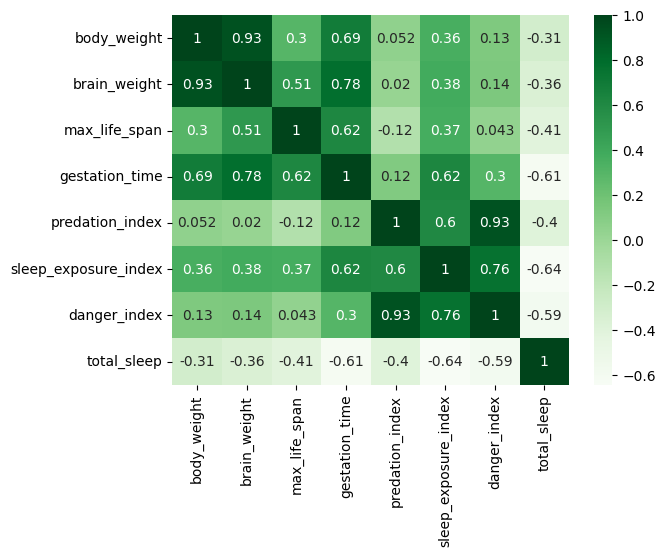

In [226]:
corr = df.corr()

sns.heatmap(corr , cmap="Greens" , annot=True)

In [227]:
x = df.iloc[: , :-1].values
y = df.iloc[: , -1].values

In [228]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x = scaler.fit_transform(x)

In [229]:
from sklearn.model_selection import train_test_split

x_train , x_test, y_train , y_test = train_test_split(x , y , test_size=0.3 , random_state=42)

In [230]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor , GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


model1 = XGBRegressor(
    n_estimators=1700,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
)

model2 = RandomForestRegressor(
    n_estimators=800,
    max_depth=6,
    random_state=42
)

model3 = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)


model = VotingRegressor(
    estimators=[
        ("xgboost", model1),
        ("random_forest", model2),
        ("decision-tree-regressor", model3),
    ]
)

model.fit(x_train, y_train)

final_pred = model.predict(x_test)

model.fit(
    x_train,
    y_train
)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xgboost', ...), ('random_forest', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None


In [231]:
y_pred = model.predict(x_test)

In [232]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print("mae ==>" , mae) 
print("mse ==>" , mse) 
print("r2  ==>" , r2) 

mae ==> 2.605395463406053
mse ==> 9.08902997248169
r2  ==> 0.646826886806696
